# Загрузка данных и библиотек
---

In [105]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.base import clone

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import RidgeClassifier

import matplotlib.pyplot as plt
import seaborn as sns
import copy

RANDOM_STATE = 0xFACED

In [2]:
train = pd.read_csv('./data/train.csv')
test = pd.read_csv('./data/test.csv')

In [3]:
train.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


# EDA
---

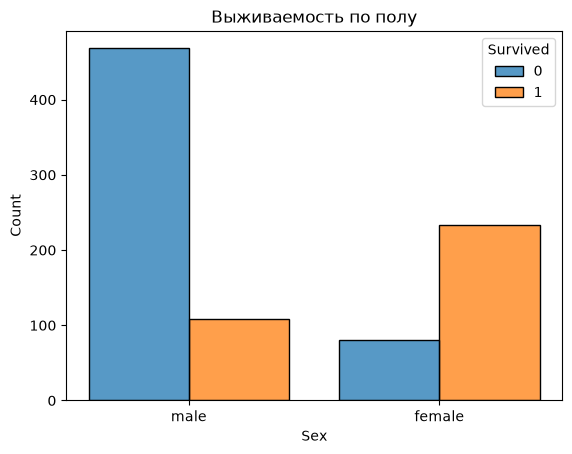

In [4]:
sns.histplot(data=train, x='Sex', hue='Survived', multiple='dodge', shrink=0.8)
plt.title('Выживаемость по полу')
plt.show()

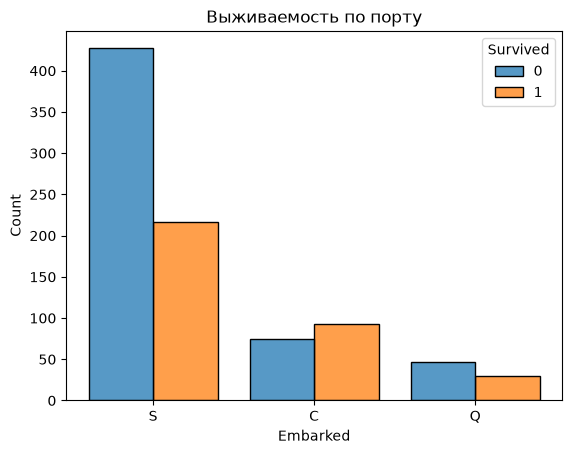

In [5]:
sns.histplot(data=train, x='Embarked', hue='Survived', multiple='dodge', shrink=0.8)
plt.title('Выживаемость по порту')
plt.show()

In [6]:
print(f"Пропуски в train по колонкам (из {train.shape[0]}):")
for col in train.columns:
    if train[col].isna().any():
        print(f"{col}: {train[col].isna().sum()}")

print(f"\nПропуски в test по колонкам (из {test.shape[0]}):")
for col in test.columns:
    if test[col].isna().any():
        print(f"{col}: {test[col].isna().sum()}")

Пропуски в train по колонкам (из 891):
Age: 177
Cabin: 687
Embarked: 2

Пропуски в test по колонкам (из 418):
Age: 86
Fare: 1
Cabin: 327


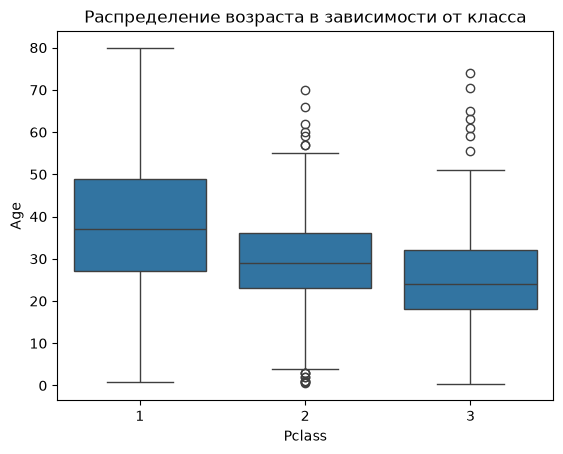

In [7]:
sns.boxplot(x='Pclass', y='Age', data=train)
plt.title('Распределение возраста в зависимости от класса')
plt.show()

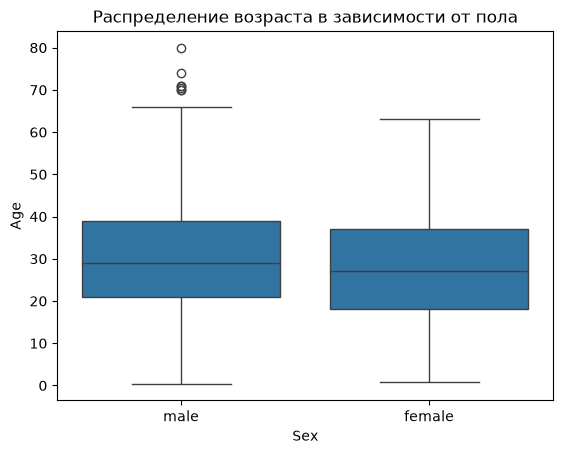

In [8]:
sns.boxplot(x='Sex', y='Age', data=train)
plt.title('Распределение возраста в зависимости от пола')
plt.show()

# Предобработка данных
---

Извлечем титул пассажира из колонки `Name`

In [9]:
train['Title'] = train['Name'].str.extract(r'([A-Za-z]+)\.')
test['Title'] = test['Name'].str.extract(r'([A-Za-z]+)\.')
train.drop('Name', axis=1, inplace=True)
test.drop('Name', axis=1, inplace=True)

In [10]:
print(train['Title'].value_counts())
print(test['Title'].value_counts())

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64
Title
Mr        240
Miss       78
Mrs        72
Master     21
Col         2
Rev         2
Ms          1
Dr          1
Dona        1
Name: count, dtype: int64


In [11]:
other_titles = ['Dr', 'Rev', 'Col', 'Major', 'Capt', 'Jonkheer', 'Don', 'Sir', 'Lady', 'Countess', 'Dona']
train['Title'] = train['Title'].replace(other_titles, 'Other')
test['Title'] = test['Title'].replace(other_titles, 'Other')

train['Title'] = train['Title'].replace(['Mlle', 'Ms'], 'Miss')
train['Title'] = train['Title'].replace('Mme', 'Mrs')
test['Title'] = test['Title'].replace(['Mlle', 'Ms'], 'Miss')
test['Title'] = test['Title'].replace('Mme', 'Mrs')

train['Title'].value_counts()

Title
Mr        517
Miss      185
Mrs       126
Master     40
Other      23
Name: count, dtype: int64

In [12]:
train.groupby('Title')['Survived'].mean().sort_values(ascending=False)

Title
Mrs       0.793651
Miss      0.702703
Master    0.575000
Other     0.347826
Mr        0.156673
Name: Survived, dtype: float64

In [13]:
train.groupby('Title')['Age'].mean().sort_values(ascending=False)

Title
Other     45.545455
Mrs       35.788991
Mr        32.368090
Miss      21.845638
Master     4.574167
Name: Age, dtype: float64

Заполним пропуски `Age` в зависимости от `Sex`, `Pclass`, `Title`

In [14]:
for dataset in (train, test):
    for sex in dataset['Sex'].unique():
        for pclass in dataset['Pclass'].unique():
            for title in dataset['Title'].unique():
                mean_age = dataset.loc[(dataset['Sex'] == sex) & 
                                       (dataset['Pclass'] == pclass) &
                                       (dataset['Title'] == title) &
                                       (dataset['Age'].notna()), 'Age'].mean()
                mask = (dataset['Age'].isna()) & (dataset['Sex'] == sex) & (dataset['Pclass'] == pclass) & (dataset['Title'] == title)
                dataset.loc[mask, 'Age'] = mean_age

Заменим порт `Embarked` на самый частый

In [15]:
train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0])

In [16]:
test[test['Fare'].isna()]

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
152,1044,3,male,60.5,0,0,3701,NaN,NaN,S,Mr


In [17]:
test.loc[test['Fare'].isna(), 'Fare'] = test.loc[(test['Fare'].notna()) & (test['Sex'] == 'male') & (test['Pclass'] == 3) & (test['Title'] == 'Mr'), 'Fare'].mean()

Насчет номеров кабинок неодназначно, можно их просто удалить, так как данных крайне мало, но появилась идея создать новый бинарный признак - известен ли номер кабинки для пассажира

In [18]:
train['HasCabin'] = train['Cabin'].notna().astype(int)
test['HasCabin'] = test['Cabin'].notna().astype(int)
train.drop('Cabin', axis=1, inplace=True)
test.drop('Cabin', axis=1, inplace=True)
train.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title,HasCabin
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,S,Mr,0
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,C,Mrs,1
2,3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S,Miss,0
3,4,1,1,female,35.0,1,0,113803,53.1000,S,Mrs,1
4,5,0,3,male,35.0,0,0,373450,8.0500,S,Mr,0


In [19]:
pd.crosstab(train['HasCabin'], train['Survived'])

Survived,0,1
HasCabin,,
0,481,206
1,68,136


Не уверен, но как-будто признак обещает быть полезным, потому что большая часть людей, чья кабинка известна - выжили.

In [20]:
pd.crosstab(train['HasCabin'], train['Pclass'])

Pclass,1,2,3
HasCabin,,,
0,40,168,479
1,176,16,12


In [21]:
train['Sex'] = (train['Sex'] == 'female').astype(int)
test['Sex'] = (test['Sex'] == 'female').astype(int)

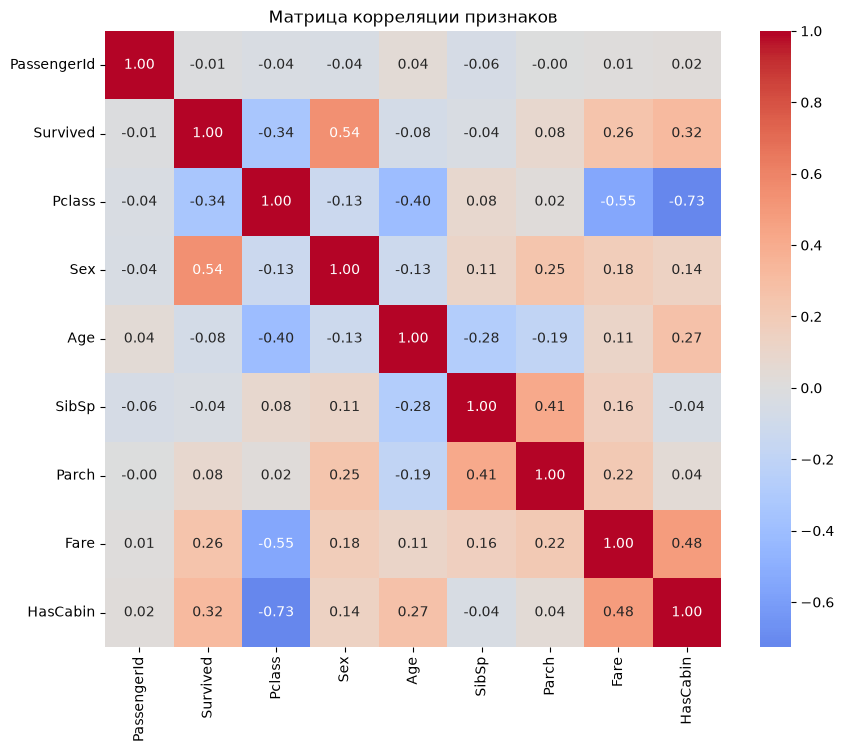

In [22]:
corr_matrix = train.select_dtypes(include='number').corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Матрица корреляции признаков')
plt.show()

Хотя с другой стороны, подавляющая часть известных номеров принадлежит первому классу, и в `Pclass` как-будто уже заложена эта информация, поэтому `HasCabin` будет лишним возможно, узнаем дальше

ГИПОТЕЗА: социальный статус, упоминаемый в Name, влияет на выживаемость, проверим позже, а пока удалим эту колонку, а также Ticket

In [23]:
train.drop(['PassengerId', 'Ticket'], axis=1, inplace=True)
test.drop(['PassengerId', 'Ticket'], axis=1, inplace=True)

train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,HasCabin
0,0,3,0,22.0,1,0,7.2500,S,Mr,0
1,1,1,1,38.0,1,0,71.2833,C,Mrs,1
2,1,3,1,26.0,0,0,7.9250,S,Miss,0
3,1,1,1,35.0,1,0,53.1000,S,Mrs,1
4,0,3,0,35.0,0,0,8.0500,S,Mr,0


Сохраняем датасет с категориальными переменными для CatBoost, для остальных моделей - применяем One-Hot-Encoding

In [24]:
train_cat = train.copy()
test_cat = test.copy()
train = pd.get_dummies(train, columns=['Embarked', 'Title'], prefix=['Emb', 'Title'])
test = pd.get_dummies(test, columns=['Embarked', 'Title'], prefix=['Emb', 'Title'])


Убираем лишние колонки после One-Hot-Encoding

In [25]:
drop_columns = ['Emb_Q', 'Title_Other']

train.drop(drop_columns, axis=1, inplace=True)
test.drop(drop_columns, axis=1, inplace=True)
train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,HasCabin,Emb_C,Emb_S,Title_Master,Title_Miss,Title_Mr,Title_Mrs
0,0,3,0,22.0,1,0,7.2500,0,False,True,False,False,True,False
1,1,1,1,38.0,1,0,71.2833,1,True,False,False,False,False,True
2,1,3,1,26.0,0,0,7.9250,0,False,True,False,True,False,False
3,1,1,1,35.0,1,0,53.1000,1,False,True,False,False,False,True
4,0,3,0,35.0,0,0,8.0500,0,False,True,False,False,True,False


In [26]:
test.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,HasCabin,Emb_C,Emb_S,Title_Master,Title_Miss,Title_Mr,Title_Mrs
0,3,0,34.5,0,0,7.8292,0,False,False,False,False,True,False
1,3,1,47.0,1,0,7.0000,0,False,True,False,False,False,True
2,2,0,62.0,0,0,9.6875,0,False,False,False,False,True,False
3,3,0,27.0,0,0,8.6625,0,False,True,False,False,True,False
4,3,1,22.0,1,1,12.2875,0,False,True,False,False,False,True


Масштабирование признаков

In [27]:
X = train.drop('Survived', axis=1)
y = train['Survived']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(test)

# Classic ML
---

## Наивный классификатор - baseline

In [28]:
dummy_model = DummyClassifier(strategy='most_frequent')
dummy_model.fit(X_train, y_train)
accuracy = dummy_model.score(X_val, y_val)
print(f"Точность наивного классификатора: {accuracy:.2f}")

Точность наивного классификатора: 0.64


## Логистическая регрессия

In [29]:
def get_fitted_logistic_regression(X_train, y_train, X_val, y_val, verbose=True):
    param_grid = [
        {
            'solver': ['lbfgs'],
            'penalty': ['l2'],
            'C': np.logspace(-3, 2, 12),
        },
        {
            'solver': ['liblinear'],
            'penalty': ['l1', 'l2'],
            'C': np.logspace(-3, 2, 12),
        },
        {
            'solver': ['saga'],
            'penalty': ['elasticnet'],
            'C': np.logspace(-3, 2, 12),
            'l1_ratio': [0.2, 0.5, 0.8]
        }
    ]

    model = GridSearchCV(LogisticRegression(max_iter=2000), param_grid, cv=5, n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    if verbose:
        print('LogisticRegression')
        print(classification_report(y_val, y_pred))
        print(pd.DataFrame.from_dict(model.best_params_, orient='index', columns=['value']))
    return model.best_estimator_

logreg_model = get_fitted_logistic_regression(X_train_scaled, y_train, X_val_scaled, y_val)

LogisticRegression
              precision    recall  f1-score   support

           0       0.91      0.94      0.92       114
           1       0.89      0.83      0.86        65

    accuracy                           0.90       179
   macro avg       0.90      0.88      0.89       179
weighted avg       0.90      0.90      0.90       179

             value
C         0.187382
penalty         l2
solver   liblinear


c:\Users\MSI\my\programming\ML\final_project\titanic\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [30]:
stats = {}

def get_accuracy_threshold(model, X_val, y_val, verbose=True):
    if hasattr(model, "predict_proba"):
        y_val_probs = model.predict_proba(X_val)[:, 1]
    elif isinstance(model, nn.Module):
        model.eval()
        with torch.no_grad():
            y_val_probs = torch.sigmoid(model(X_val)).cpu().numpy().flatten()
    
    best_threshold = 0.5
    best_accuracy = 0.0

    for threshold in np.arange(0.1, 0.9, 0.01):
        preds = (y_val_probs >= threshold).astype(int)
        current_accuracy = accuracy_score(y_val, preds)
        if current_accuracy > best_accuracy:
            best_accuracy = current_accuracy
            best_threshold = threshold

    if verbose:
        print(f'best threshold: {best_threshold:.2f}')
        print(f'best accuracy:  {best_accuracy:.4f}')
    return best_accuracy, best_threshold

stats['LogisticRegression'] = get_accuracy_threshold(logreg_model, X_val_scaled, y_val)

best threshold: 0.54
best accuracy:  0.9050


Отображаем важность признаков

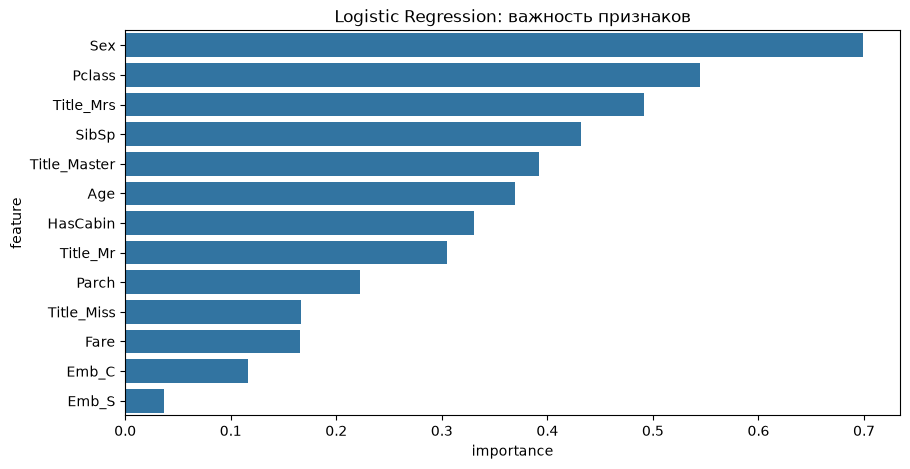

In [31]:
coefs = logreg_model.coef_[0]
features = X_train.columns

importance_df = pd.DataFrame({'feature': features, 'importance': np.abs(coefs)})
importance_df = importance_df.sort_values('importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=importance_df, x='importance', y='feature')
plt.title('Logistic Regression: важность признаков')
plt.show()

## KNN

In [32]:
def get_fitted_knn(X_train, y_train, X_val, y_val, verbose=True):
    param_grid = {
        'n_neighbors': np.arange(1, 50),
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan', 'minkowski'],
        'p': [1, 2, 3]
    }

    model = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    if verbose:
        print('KNeighborsClassifier')
        print(classification_report(y_val, y_pred))
        print(pd.DataFrame.from_dict(model.best_params_, orient='index', columns=['value']))
    return model.best_estimator_

knn_model = get_fitted_knn(X_train_scaled, y_train, X_val_scaled, y_val)

KNeighborsClassifier
              precision    recall  f1-score   support

           0       0.85      0.94      0.89       114
           1       0.87      0.71      0.78        65

    accuracy                           0.85       179
   macro avg       0.86      0.82      0.84       179
weighted avg       0.86      0.85      0.85       179

                 value
metric       manhattan
n_neighbors          9
p                    1
weights        uniform


Попробуем убрать колонки с титулами

In [33]:
X_knn = train.drop(columns=['Survived', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs'])
X_knn_train, X_knn_val, y_knn_train, y_knn_val = train_test_split(X_knn, y, test_size=0.2, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_knn_train_scaled = scaler.fit_transform(X_knn_train)
X_knn_val_scaled = scaler.transform(X_knn_val)

In [34]:
knn_model = get_fitted_knn(X_knn_train_scaled, y_knn_train, X_knn_val_scaled, y_knn_val)

KNeighborsClassifier
              precision    recall  f1-score   support

           0       0.85      0.97      0.91       114
           1       0.94      0.71      0.81        65

    accuracy                           0.88       179
   macro avg       0.90      0.84      0.86       179
weighted avg       0.88      0.88      0.87       179

                 value
metric       manhattan
n_neighbors          9
p                    1
weights        uniform


In [35]:
stats['KNeighborsClassifier'] = get_accuracy_threshold(knn_model, X_knn_val_scaled, y_knn_val)

best threshold: 0.45
best accuracy:  0.8771


## Дерево решений

In [36]:
def get_fitted_decision_tree(X_train, y_train, X_val, y_val, verbose=True):
    param_grid = {
        'criterion': ['gini', 'entropy', 'log_loss'],
        'max_depth': [None, 2, 3, 4, 5, 7, 10, 12, 15], 
        'min_samples_split': np.arange(2, 30, 2),
        'min_samples_leaf': np.arange(1, 20, 2),
        'max_features': [None, 'sqrt', 'log2', 0.5, 0.7] 
    }

    model = RandomizedSearchCV(DecisionTreeClassifier(), param_distributions=param_grid, n_iter=300, cv=5, random_state=RANDOM_STATE, n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    if verbose:
        print('DecisionTreeClassifier')
        print(classification_report(y_val, y_pred))
        print(pd.DataFrame.from_dict(model.best_params_, orient='index', columns=['value']))
    return model.best_estimator_

tree_model = get_fitted_decision_tree(X_train, y_train, X_val, y_val)

DecisionTreeClassifier
              precision    recall  f1-score   support

           0       0.86      0.91      0.89       114
           1       0.83      0.74      0.78        65

    accuracy                           0.85       179
   macro avg       0.84      0.83      0.83       179
weighted avg       0.85      0.85      0.85       179

                  value
min_samples_split     2
min_samples_leaf      5
max_features        0.7
max_depth            10
criterion          gini


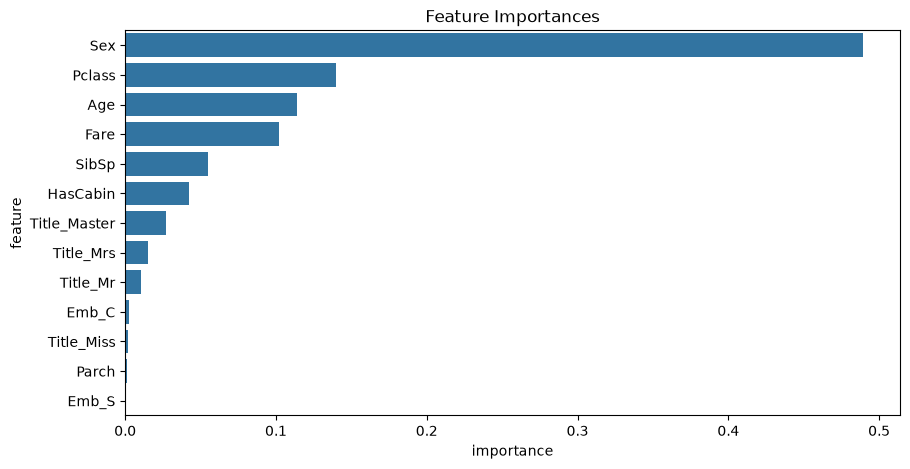

In [37]:
importances = tree_model.feature_importances_
features = X_train.columns
importance_df = pd.DataFrame({'feature': features, 'importance': importances})
importance_df = importance_df.sort_values('importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=importance_df, x='importance', y='feature')
plt.title('Feature Importances')
plt.show()

Пропробуем убрать неважные признаки

In [38]:
X_tree = train.drop(columns=['Survived', 'Title_Miss', 'Title_Mrs', 'Title_Master'])
X_tree_train, X_tree_val, y_tree_train, y_tree_val = train_test_split(X_tree, y, test_size=0.2, random_state=RANDOM_STATE)

In [39]:
tree_model = get_fitted_decision_tree(X_tree_train, y_tree_train, X_tree_val, y_tree_val)

DecisionTreeClassifier
              precision    recall  f1-score   support

           0       0.82      0.97      0.89       114
           1       0.93      0.63      0.75        65

    accuracy                           0.85       179
   macro avg       0.88      0.80      0.82       179
weighted avg       0.86      0.85      0.84       179

                  value
min_samples_split    16
min_samples_leaf     17
max_features       sqrt
max_depth            12
criterion          gini


In [40]:
stats['DecisionTreeClassifier'] = get_accuracy_threshold(tree_model, X_tree_val, y_tree_val)

best threshold: 0.32
best accuracy:  0.8603


## Random Forest

In [41]:
def get_fitted_random_forest(X_train, y_train, X_val, y_val, verbose=True):
    param_grid = {
        'criterion': ['gini', 'entropy'],
        'max_samples': [0.5, 0.7, 0.9, None],
        'max_depth': [2, 3, 4, 5],
        'max_features': ['sqrt', 'log2', 0.4, 0.6],
        'min_samples_split': [2, 4, 5, 7, 10],
        'min_samples_leaf': [1, 2, 4, 5, 7, 10],
    }

    model = RandomizedSearchCV(RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE), param_grid, n_iter=100, cv=5, random_state=RANDOM_STATE, n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    if verbose:
        print('RandomForestClassifier')
        print(classification_report(y_val, y_pred))
        print(pd.DataFrame.from_dict(model.best_params_, orient='index', columns=['value']))
    return model.best_estimator_

rf_model = get_fitted_random_forest(X_tree_train, y_tree_train, X_tree_val, y_tree_val)

RandomForestClassifier
              precision    recall  f1-score   support

           0       0.87      0.95      0.91       114
           1       0.89      0.75      0.82        65

    accuracy                           0.88       179
   macro avg       0.88      0.85      0.86       179
weighted avg       0.88      0.88      0.87       179

                  value
min_samples_split    10
min_samples_leaf      2
max_samples         0.9
max_features       sqrt
max_depth             5
criterion          gini


In [42]:
rf_model.set_params(n_estimators=300)
rf_model.fit(X_tree_train, y_tree_train)

stats['RandomForestClassifier'] = get_accuracy_threshold(rf_model, X_tree_val, y_tree_val)

best threshold: 0.34
best accuracy:  0.8883


## CatBoost

Подготовка данных для CatBoost

In [43]:
X_cat = train_cat.drop('Survived', axis=1)
y_cat = train_cat['Survived']

X_cat_train, X_cat_val, y_cat_train, y_cat_val = train_test_split(X_cat, y_cat, test_size=0.2, random_state=RANDOM_STATE)

In [44]:
def get_fitted_catboost(X_train, y_train, X_val, y_val, cat_features, verbose=True):
    catboost_model = CatBoostClassifier(
        iterations=1500,
        depth=5,
        loss_function='Logloss',
        random_seed=42
    )
    if verbose: 
        print('CatBoostClassifier')
    catboost_model.fit(X_cat_train, y_cat_train, eval_set=(X_cat_val, y_cat_val), cat_features=cat_features, early_stopping_rounds=100, verbose=100*verbose)
    y_cat_pred = catboost_model.predict(X_cat_val)
    if verbose:
        print(classification_report(y_cat_val, y_cat_pred))
    return catboost_model

catboost_model = get_fitted_catboost(X_cat_train, y_cat_train, X_cat_val, y_cat_val, cat_features=['Title', 'Embarked'])

CatBoostClassifier
Learning rate set to 0.024427
0:	learn: 0.6771537	test: 0.6779696	best: 0.6779696 (0)	total: 190ms	remaining: 4m 45s
100:	learn: 0.3966429	test: 0.3749513	best: 0.3749513 (100)	total: 2.52s	remaining: 34.9s
200:	learn: 0.3654980	test: 0.3596405	best: 0.3596405 (200)	total: 4.8s	remaining: 31s
300:	learn: 0.3446710	test: 0.3593934	best: 0.3565893 (223)	total: 7.04s	remaining: 28s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.3565892559
bestIteration = 223

Shrink model to first 224 iterations.
              precision    recall  f1-score   support

           0       0.86      0.96      0.90       114
           1       0.90      0.72      0.80        65

    accuracy                           0.87       179
   macro avg       0.88      0.84      0.85       179
weighted avg       0.87      0.87      0.87       179



In [45]:
stats['CatBoostClassifier'] = get_accuracy_threshold(catboost_model, X_cat_val, y_cat_val)

best threshold: 0.35
best accuracy:  0.8994


## LightGBM

In [46]:
X_lgbm = train.drop(columns=['Survived'])
X_lgbm_train, X_lgbm_val, y_lgbm_train, y_lgbm_val = train_test_split(X_lgbm, y, test_size=0.2, random_state=RANDOM_STATE)

In [47]:
def get_fitted_lightgbm(X_train, y_train, X_val, y_val, verbose=True):
    lgbm_model = LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)

    param_grid = {
        'n_estimators': [50, 100, 200],
        'learning_rate': np.linspace(0.01, 0.1, 5),
        'num_leaves': np.arange(5, 20, 3),
        'max_depth': [-1, 3, 5, 7],
        'min_child_samples': [10, 15, 20, 25, 30]
    }

    model = RandomizedSearchCV(lgbm_model, param_grid, n_iter=200, scoring='accuracy', cv=5, n_jobs=-1, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    if verbose:
        print('LGBMClassifier')
        print(classification_report(y_val, y_pred))
        print(pd.DataFrame.from_dict(model.best_params_, orient='index', columns=['value']))
    return model.best_estimator_

lgbm_model = get_fitted_lightgbm(X_lgbm_train, y_lgbm_train, X_lgbm_val, y_lgbm_val)

LGBMClassifier
              precision    recall  f1-score   support

           0       0.86      0.94      0.90       114
           1       0.87      0.72      0.79        65

    accuracy                           0.86       179
   macro avg       0.86      0.83      0.84       179
weighted avg       0.86      0.86      0.86       179

                   value
num_leaves           5.0
n_estimators       200.0
min_child_samples   30.0
max_depth            3.0
learning_rate        0.1


In [48]:
stats['LGBMClassifier'] = get_accuracy_threshold(lgbm_model, X_lgbm_val, y_lgbm_val)

best threshold: 0.29
best accuracy:  0.8659


## XGBoost

In [49]:
def get_fitted_xgboost(X_train, y_train, X_val, y_val, verbose=True):
    xgb_model = XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=-1)

    param_grid = {
        'n_estimators': np.arange(50, 301, 50),
        'learning_rate': np.linspace(0.01, 0.1, 5),
        'max_depth': [3, 4, 5, 6, 7],
        'min_child_weight': [1, 2, 4, 6, 8, 10],
        'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0]
    }

    model = RandomizedSearchCV(xgb_model, param_grid, n_iter=100, scoring='accuracy', cv=5, n_jobs=-1, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    y_xgb_pred = model.predict(X_val)
    if verbose:
        print('XGBClassifier')
        print(classification_report(y_val, y_xgb_pred))
        print(pd.DataFrame.from_dict(model.best_params_, orient='index', columns=['value']))
    return model.best_estimator_

xgb_model = get_fitted_xgboost(X_tree_train, y_tree_train, X_tree_val, y_tree_val)

XGBClassifier
              precision    recall  f1-score   support

           0       0.86      0.95      0.90       114
           1       0.89      0.72      0.80        65

    accuracy                           0.87       179
   macro avg       0.87      0.84      0.85       179
weighted avg       0.87      0.87      0.86       179

                  value
subsample           0.8
n_estimators       50.0
min_child_weight    2.0
max_depth           5.0
learning_rate       0.1
colsample_bytree    0.6


In [50]:
stats['XGBClassifier'] = get_accuracy_threshold(xgb_model, X_tree_val, y_tree_val)

best threshold: 0.35
best accuracy:  0.8883


# Итоги по Classic ML

In [51]:
def print_sorted_stats(stats):
    stats = dict(sorted(stats.items(), key=lambda x: x[1][0], reverse=True))

    print('┌' + '─' * 24 + '┬' + '─' * 10 + '┬' + '─' * 11 + '┐')
    print(f"│ {'Classifier':<22} │ {'Accuracy':<8} │ {'Threshold':<9} │")
    print('├' + '─' * 24 + '┼' + '─' * 10 + '┼' + '─' * 11 + '┤')
    for model_name, (accuracy, threshold) in stats.items():
        print(f"│ {model_name:<22} │ {accuracy:<8.4f} │ {threshold:<10.2f}│")
    print('└' + '─' * 24 + '┴' + '─' * 10 + '┴' + '─' * 11 + '┘')

print_sorted_stats(stats)

┌────────────────────────┬──────────┬───────────┐
│ Classifier             │ Accuracy │ Threshold │
├────────────────────────┼──────────┼───────────┤
│ LogisticRegression     │ 0.9050   │ 0.54      │
│ CatBoostClassifier     │ 0.8994   │ 0.35      │
│ RandomForestClassifier │ 0.8883   │ 0.34      │
│ XGBClassifier          │ 0.8883   │ 0.35      │
│ KNeighborsClassifier   │ 0.8771   │ 0.45      │
│ LGBMClassifier         │ 0.8659   │ 0.29      │
│ DecisionTreeClassifier │ 0.8603   │ 0.32      │
└────────────────────────┴──────────┴───────────┘


# Deep Learning
---

In [52]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [53]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).to(device)
X_val_tensor   = torch.tensor(X_val_scaled,   dtype=torch.float32).to(device)
y_val_tensor   = torch.tensor(y_val.values,   dtype=torch.float32).to(device)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

## Первая версия

In [54]:
class NN1(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.layer_1 = nn.Linear(input_dim, 16)
        self.layer_2 = nn.Linear(16, 16)
        self.layer_3 = nn.Linear(16, 1)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.layer_1(x)
        x = self.relu(x)
        x = self.layer_2(x)
        x = self.relu(x)
        x = self.layer_3(x)
        return x

input_dim = X_train_tensor.shape[1]
nn1_model = NN1(input_dim).to(device)

In [55]:
class_counts = y_train.value_counts()
pos_weight = torch.tensor([class_counts[0] / class_counts[1]], dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.Adam(nn1_model.parameters(), lr=0.001)

In [56]:
EPOCHS = 100
train_losses, val_losses = [], []
train_acc, val_acc = [], []

for epoch in range(EPOCHS):
    nn1_model.train()
    train_loss = 0
    true_answer = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = nn1_model(X_batch)
        y_batch = y_batch.view(-1, 1)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        probs = torch.sigmoid(y_pred)
        preds_classes = (probs >= 0.5).float()
        true_answer += (preds_classes == y_batch).sum().item()

    train_losses.append(train_loss / len(train_loader))
    train_acc.append(true_answer / len(y_train_tensor))

    nn1_model.eval()
    with torch.no_grad():
        y_val_pred = nn1_model(X_val_tensor)
        y_val_target = y_val_tensor.view(-1, 1)
        val_loss = criterion(y_val_pred, y_val_target).item()

        val_probs = torch.sigmoid(y_val_pred)
        val_preds_classes = (val_probs >= 0.5).float()
        val_true_answer = (val_preds_classes == y_val_target).sum().item()

    val_losses.append(val_loss)
    val_acc.append(val_true_answer / len(y_val_tensor))
    if (epoch + 1) % 10 == 0:
        print(f'[EPOCH {epoch+1:3}/{EPOCHS}] train_loss: {train_losses[-1]:.4f}, train_acc: {train_acc[-1]:.4f} | val_loss: {val_losses[-1]:.4f}, val_acc: {val_acc[-1]:.4f}')

[EPOCH  10/100] train_loss: 0.5589, train_acc: 0.7992 | val_loss: 0.4813, val_acc: 0.8659
[EPOCH  20/100] train_loss: 0.5194, train_acc: 0.8258 | val_loss: 0.4348, val_acc: 0.8939
[EPOCH  30/100] train_loss: 0.5070, train_acc: 0.8329 | val_loss: 0.4269, val_acc: 0.8939
[EPOCH  40/100] train_loss: 0.5095, train_acc: 0.8385 | val_loss: 0.4289, val_acc: 0.8883
[EPOCH  50/100] train_loss: 0.4923, train_acc: 0.8385 | val_loss: 0.4265, val_acc: 0.8939
[EPOCH  60/100] train_loss: 0.4958, train_acc: 0.8427 | val_loss: 0.4237, val_acc: 0.8939
[EPOCH  70/100] train_loss: 0.4961, train_acc: 0.8427 | val_loss: 0.4265, val_acc: 0.8939
[EPOCH  80/100] train_loss: 0.4875, train_acc: 0.8413 | val_loss: 0.4253, val_acc: 0.8883
[EPOCH  90/100] train_loss: 0.4883, train_acc: 0.8427 | val_loss: 0.4186, val_acc: 0.8939
[EPOCH 100/100] train_loss: 0.4662, train_acc: 0.8413 | val_loss: 0.4217, val_acc: 0.8883


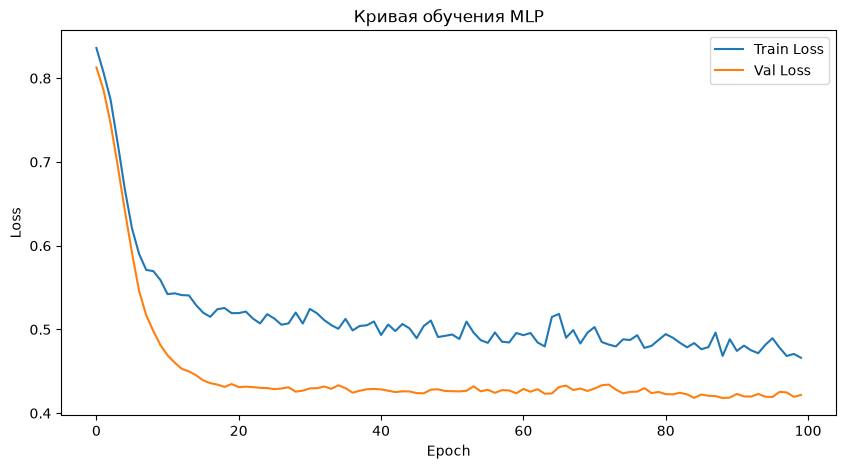

In [57]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Кривая обучения MLP')
plt.show()

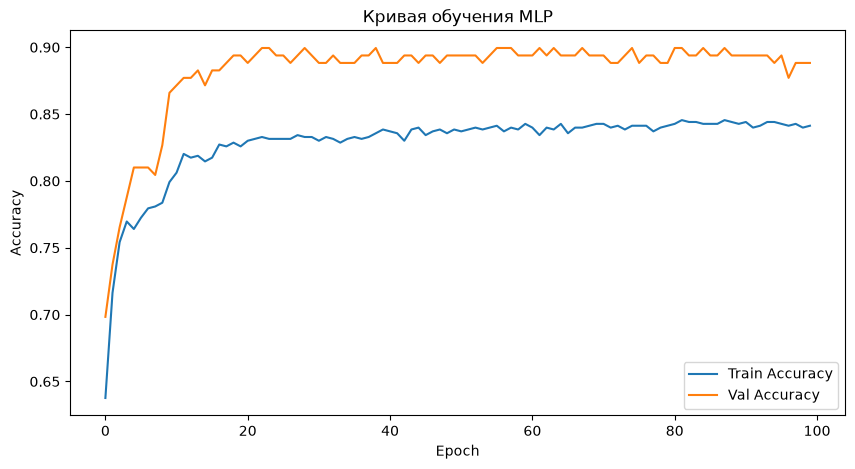

In [58]:
plt.figure(figsize=(10, 5))
plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Кривая обучения MLP')
plt.show()

In [59]:
stats['NN1'] = get_accuracy_threshold(nn1_model, X_val_tensor, y_val)

best threshold: 0.47
best accuracy:  0.8994


## Добавляем BatchNorm, DropOut, Early Stopping

In [60]:
class NN2(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.layer_1 = nn.Linear(input_dim, 32)
        self.bn1 = nn.BatchNorm1d(32)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3)

        self.layer_2 = nn.Linear(32, 16)
        self.bn2 = nn.BatchNorm1d(16)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.2)

        self.layer_3 = nn.Linear(16, 1)
    
    def forward(self, x):
        x = self.dropout1(self.relu1(self.bn1(self.layer_1(x))))
        x = self.dropout2(self.relu2(self.bn2(self.layer_2(x))))
        return self.layer_3(x)

input_dim = X_train_tensor.shape[1]
nn2_model = NN2(input_dim).to(device)

In [61]:
class_counts = y_train.value_counts()
pos_weight = torch.tensor([class_counts[0] / class_counts[1]], dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.Adam(nn2_model.parameters(), lr=0.001, weight_decay=1e-4)

In [62]:
EPOCHS = 150
train_losses, val_losses = [], []
train_acc, val_acc = [], []

best_val_loss = float('inf')
best_model_weights = None

for epoch in range(EPOCHS):
    nn2_model.train()
    train_loss = 0
    true_answer = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = nn2_model(X_batch)
        y_batch = y_batch.view(-1, 1)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        probs = torch.sigmoid(y_pred)
        preds_classes = (probs >= 0.5).float()
        true_answer += (preds_classes == y_batch).sum().item()
    
    train_losses.append(train_loss / len(train_loader))
    train_acc.append(true_answer / len(y_train_tensor))

    nn2_model.eval()
    with torch.no_grad():
        y_val_pred = nn2_model(X_val_tensor)
        y_val_target = y_val_tensor.view(-1, 1)
        val_loss = criterion(y_val_pred, y_val_target).item()

        val_probs = torch.sigmoid(y_val_pred)
        val_preds_classes = (val_probs >= 0.5).float()
        val_true_answer = (val_preds_classes == y_val_target).sum().item()

    val_losses.append(val_loss)
    val_acc.append(val_true_answer / len(y_val_tensor))

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_weights = copy.deepcopy(nn2_model.state_dict())
    
    if (epoch + 1) % 10 == 0:
        print(f'[EPOCH {epoch+1:3}/{EPOCHS}] train_loss: {train_losses[-1]:.4f}, train_acc: {train_acc[-1]:.4f} | val_loss: {val_losses[-1]:.4f}, val_acc: {val_acc[-1]:.4f}')
        

[EPOCH  10/150] train_loss: 0.6006, train_acc: 0.7753 | val_loss: 0.5020, val_acc: 0.8492
[EPOCH  20/150] train_loss: 0.5562, train_acc: 0.8034 | val_loss: 0.4609, val_acc: 0.8939
[EPOCH  30/150] train_loss: 0.5412, train_acc: 0.8174 | val_loss: 0.4434, val_acc: 0.8939
[EPOCH  40/150] train_loss: 0.5276, train_acc: 0.8090 | val_loss: 0.4503, val_acc: 0.8827
[EPOCH  50/150] train_loss: 0.5082, train_acc: 0.8315 | val_loss: 0.4537, val_acc: 0.8939
[EPOCH  60/150] train_loss: 0.5360, train_acc: 0.8076 | val_loss: 0.4461, val_acc: 0.8827
[EPOCH  70/150] train_loss: 0.5508, train_acc: 0.8287 | val_loss: 0.4557, val_acc: 0.8771
[EPOCH  80/150] train_loss: 0.5185, train_acc: 0.8202 | val_loss: 0.4457, val_acc: 0.8939
[EPOCH  90/150] train_loss: 0.5449, train_acc: 0.8230 | val_loss: 0.4469, val_acc: 0.8883
[EPOCH 100/150] train_loss: 0.5318, train_acc: 0.8301 | val_loss: 0.4575, val_acc: 0.8883
[EPOCH 110/150] train_loss: 0.5289, train_acc: 0.8371 | val_loss: 0.4497, val_acc: 0.8827
[EPOCH 120

In [63]:
stats['NN2'] = get_accuracy_threshold(nn2_model, X_val_tensor, y_val)

best threshold: 0.45
best accuracy:  0.8939


## Добавляем Scheduler, меняем функции активации

In [64]:
class NN3(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.layer_1 = nn.Linear(input_dim, 32)
        self.bn1 = nn.BatchNorm1d(32)
        self.silu1 = nn.SiLU()
        self.dropout1 = nn.Dropout(0.3)

        self.layer_2 = nn.Linear(32, 16)
        self.bn2 = nn.BatchNorm1d(16)
        self.silu2 = nn.SiLU()
        self.dropout2 = nn.Dropout(0.2)

        self.layer_3 = nn.Linear(16, 1)
    
    def forward(self, x):
        x = self.dropout1(self.silu1(self.bn1(self.layer_1(x))))
        x = self.dropout2(self.silu2(self.bn2(self.layer_2(x))))
        return self.layer_3(x)

input_dim = X_train_tensor.shape[1]
nn3_model = NN3(input_dim).to(device)

In [65]:
class_counts = y_train.value_counts()
pos_weight = torch.tensor([class_counts[0] / class_counts[1]], dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.Adam(nn3_model.parameters(), lr=0.005, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=10, factor=0.1)

In [66]:
def get_fitted_nn(nn_model, train_loader, X_val, y_val, scheduler, EPOCHS, early_stopping=True, verbose=True):
    train_losses, val_losses = [], []
    train_acc, val_acc = [], []
    if early_stopping:
        best_val_loss = float('inf')
        best_model_weights = None

    for epoch in range(EPOCHS):
        nn_model.train()
        train_loss = 0
        true_answer = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = nn_model(X_batch)
            y_batch = y_batch.view(-1, 1)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            probs = torch.sigmoid(y_pred)
            preds_classes = (probs >= 0.5).float()
            true_answer += (preds_classes == y_batch).sum().item()
        
        train_losses.append(train_loss / len(train_loader))
        train_acc.append(true_answer / len(y_train_tensor))

        nn_model.eval()
        with torch.no_grad():
            y_val_pred = nn_model(X_val)
            y_val_target = y_val.view(-1, 1)
            val_loss = criterion(y_val_pred, y_val_target).item()

            val_probs = torch.sigmoid(y_val_pred)
            val_preds_classes = (val_probs >= 0.5).float()
            val_true_answer = (val_preds_classes == y_val_target).sum().item()

        val_losses.append(val_loss)
        val_acc.append(val_true_answer / len(y_val))

        if early_stopping and val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_weights = copy.deepcopy(nn_model.state_dict())
        scheduler.step(val_loss)
        if verbose and (epoch + 1) % 10 == 0:
            print(f'[EPOCH {epoch+1:3}/{EPOCHS}] train_loss: {train_losses[-1]:.4f}, train_acc: {train_acc[-1]:.4f} | val_loss: {val_losses[-1]:.4f}, val_acc: {val_acc[-1]:.4f}')
    if early_stopping:
        nn_model.load_state_dict(best_model_weights)
        nn_model.eval()
    return nn_model, (train_losses, val_losses, train_acc, val_acc)


nn3_model, nn_stats = get_fitted_nn(nn3_model, train_loader, X_val_tensor, y_val_tensor, scheduler, EPOCHS=150)
train_losses, val_losses, train_acc, val_acc = nn_stats

[EPOCH  10/150] train_loss: 0.5281, train_acc: 0.8160 | val_loss: 0.4615, val_acc: 0.8939
[EPOCH  20/150] train_loss: 0.5788, train_acc: 0.8188 | val_loss: 0.4332, val_acc: 0.8771
[EPOCH  30/150] train_loss: 0.5201, train_acc: 0.8258 | val_loss: 0.4428, val_acc: 0.8883
[EPOCH  40/150] train_loss: 0.5343, train_acc: 0.8174 | val_loss: 0.4428, val_acc: 0.8883
[EPOCH  50/150] train_loss: 0.5314, train_acc: 0.8160 | val_loss: 0.4468, val_acc: 0.8939
[EPOCH  60/150] train_loss: 0.5286, train_acc: 0.8258 | val_loss: 0.4458, val_acc: 0.8883
[EPOCH  70/150] train_loss: 0.5105, train_acc: 0.8132 | val_loss: 0.4424, val_acc: 0.8883
[EPOCH  80/150] train_loss: 0.5064, train_acc: 0.8258 | val_loss: 0.4467, val_acc: 0.8939
[EPOCH  90/150] train_loss: 0.5543, train_acc: 0.8188 | val_loss: 0.4403, val_acc: 0.8883
[EPOCH 100/150] train_loss: 0.5257, train_acc: 0.8146 | val_loss: 0.4443, val_acc: 0.8939
[EPOCH 110/150] train_loss: 0.5400, train_acc: 0.8034 | val_loss: 0.4469, val_acc: 0.8939
[EPOCH 120

In [67]:
stats['NN3'] = get_accuracy_threshold(nn3_model, X_val_tensor, y_val)

best threshold: 0.54
best accuracy:  0.8994


# Итоги по Classic ML & DL

In [68]:
print_sorted_stats(stats)

┌────────────────────────┬──────────┬───────────┐
│ Classifier             │ Accuracy │ Threshold │
├────────────────────────┼──────────┼───────────┤
│ LogisticRegression     │ 0.9050   │ 0.54      │
│ CatBoostClassifier     │ 0.8994   │ 0.35      │
│ NN1                    │ 0.8994   │ 0.47      │
│ NN3                    │ 0.8994   │ 0.54      │
│ NN2                    │ 0.8939   │ 0.45      │
│ RandomForestClassifier │ 0.8883   │ 0.34      │
│ XGBClassifier          │ 0.8883   │ 0.35      │
│ KNeighborsClassifier   │ 0.8771   │ 0.45      │
│ LGBMClassifier         │ 0.8659   │ 0.29      │
│ DecisionTreeClassifier │ 0.8603   │ 0.32      │
└────────────────────────┴──────────┴───────────┘


# Feature Engineering
---

Добавим следующие признаки:
- `Family_Size` - общее кол-во человек в семье
- `Is_Alone` - одинокий ли человек
- `Age_Class` - произведение возраста и номера класса
- `Deck` - название палубы из номера каюты
- `Fare_Per_Person` - цена билета на одного человека
- `Title` - обработаем редкие титулы более точно
- `Is_Mother` - статус Мать
- `Family_Survival` - живучесть группы / семьи

Напишем итоговый препроцессинг

In [69]:
train = pd.read_csv('./data/train.csv')
test = pd.read_csv('./data/test.csv')
df = pd.concat([train, test], sort=False).reset_index(drop=True)

def preprocessing(df):
    df['Family_Size'] = df['SibSp'] + df['Parch'] + 1
    
    df['Is_Alone'] = (df['Family_Size'] == 1).astype(int)

    df['Deck'] = df['Cabin'].apply(lambda x: str(x)[0] if pd.notnull(x) else 'Unknown')
    df['Deck'] = df['Deck'].replace({'T': 'Unknown', 'G': 'F'})

    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    title_dict = {
        'Capt': 'Officer', 'Col': 'Officer', 'Major': 'Officer', 'Dr': 'Officer', 'Rev': 'Officer',
        'Jonkheer': 'Royalty', 'Don': 'Royalty', 'Sir': 'Royalty', 'Countess': 'Royalty', 'Lady': 'Royalty', 'Dona': 'Royalty',
        'Mme': 'Mrs', 'Ms': 'Miss', 'Mlle': 'Miss', 'Mr': 'Mr', 'Mrs': 'Mrs', 'Miss': 'Miss', 'Master': 'Master'
    }
    df['Title'] = df['Title'].map(title_dict)

    df['Is_Mother'] = 0
    df.loc[(df['Age'] > 18) & (df['Sex'] == 'female') & (df['Parch'] > 0), 'Is_Mother'] = 1

    df['LastName'] = df['Name'].apply(lambda x: x.split(',')[0].strip())

    df['Group_ID'] = df['LastName'] + '_' + df['Ticket']

    df['Family_Survival'] = 0.5
    for grp, group_df in df.groupby('Group_ID'):
        if len(group_df) > 1:
            for ind, row in group_df.iterrows():
                other_members = group_df.drop(ind)
                max_s = other_members['Survived'].max()
                min_s = other_members['Survived'].min()
                if max_s == 1.0:
                    df.loc[ind, 'Family_Survival'] = 1.0
                elif min_s == 0.0:
                    df.loc[ind, 'Family_Survival'] = 0.0
    df = df.drop(columns=['Group_ID']) # 'LastName', 

    # Старая предобработка
    for sex in df['Sex'].unique():
        for pclass in df['Pclass'].unique():
            for title in df['Title'].unique():
                mean_age = df.loc[(df['Sex'] == sex) & 
                                    (df['Pclass'] == pclass) &
                                    (df['Title'] == title) &
                                    (df['Age'].notna()), 'Age'].mean()
                mask = (df['Age'].isna()) & (df['Sex'] == sex) & (df['Pclass'] == pclass) & (df['Title'] == title)
                df.loc[mask, 'Age'] = mean_age
    
    df['Age_Class'] = df['Age'] * df['Pclass']
    
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    
    df.loc[df['Fare'].isna(), 'Fare'] = df.loc[(df['Fare'].notna()) & (df['Sex'] == 'male') & (df['Pclass'] == 3) & (df['Title'] == 'Mr'), 'Fare'].mean()

    ticket_counts = df['Ticket'].value_counts()
    df['Ticket_Frequency'] = df['Ticket'].map(ticket_counts)
    df['Fare_Per_Person'] = df['Fare'] / df['Ticket_Frequency']

    df['HasCabin'] = df['Cabin'].notna().astype(int)
    #df.drop('Cabin', axis=1, inplace=True)
    df['Sex'] = (df['Sex'] == 'female').astype(int)
    
    df.drop(['PassengerId', 'Ticket', 'Name', 'Cabin'], axis=1, inplace=True)

    df_cat = df.copy()
    train_cat = df_cat[df_cat['Survived'].notnull()].copy()
    test_cat = df_cat[df_cat['Survived'].isnull()].copy().drop(columns=['Survived'])

    df = pd.get_dummies(df, columns=['Embarked', 'Title', 'Deck'], prefix=['Emb', 'Title', 'Deck'])

    drop_columns = [ 'LastName']
    df.drop(drop_columns, axis=1, inplace=True)

    train = df[df['Survived'].notnull()].copy()
    test = df[df['Survived'].isnull()].copy().drop(columns=['Survived'])

    return train, test, train_cat, test_cat

train, test, train_cat, test_cat = preprocessing(df)

X = train.drop('Survived', axis=1)
y = train['Survived']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(test)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

## Обучение моделей

In [70]:
stats_new = {}

In [71]:
X_lr = X#.drop(columns=['Emb_Q', 'Deck_F', 'Is_Alone', 'Fare'])
X_lr_train, X_lr_val, y_lr_train, y_lr_val = train_test_split(X_lr, y, test_size=0.2, random_state=RANDOM_STATE)
X_lr_train_scaled = scaler.fit_transform(X_lr_train)
X_lr_val_scaled = scaler.transform(X_lr_val)

logreg_model = get_fitted_logistic_regression(X_lr_train_scaled, y_lr_train, X_lr_val_scaled, y_lr_val, verbose=False)
stats_new['LogisticRegression'] = get_accuracy_threshold(logreg_model, X_lr_val_scaled, y_lr_val, verbose=False)

c:\Users\MSI\my\programming\ML\final_project\titanic\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [72]:
X_knn = X#.drop(columns=['Deck_A', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_Unknown', 'HasCabin', 'Ticket_Frequency', 'Family_Size', 'SibSp', 'Title_Royalty', 'Title_Officer', 'Emb_S', 'Fare'])
X_knn_train, X_knn_val, y_knn_train, y_knn_val = train_test_split(X_knn, y, test_size=0.2, random_state=RANDOM_STATE)
X_knn_train = scaler.fit_transform(X_knn_train)
X_knn_val = scaler.transform(X_knn_val)

knn_model = get_fitted_knn(X_knn_train, y_knn_train, X_knn_val, y_knn_val, verbose=False)
stats_new['KNeighborsClassifier'] = get_accuracy_threshold(knn_model, X_knn_val, y_knn_val, verbose=False)

In [73]:
X_tree = X#.drop(columns=['Deck_A', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_Unknown', 'Title_Royalty', 'Is_Alone', 'Is_Mother', 'Emb_C', 'Emb_Q', 'Emb_S'])

X_tree_train, X_tree_val, y_tree_train, y_tree_val = train_test_split(X_tree, y, test_size=0.2, random_state=RANDOM_STATE)
tree_model = get_fitted_decision_tree(X_tree_train, y_tree_train, X_tree_val, y_tree_val, verbose=False)
stats_new['DecisionTreeClassifier'] = get_accuracy_threshold(tree_model, X_tree_val, y_tree_val, verbose=False)

In [74]:
rf_model = get_fitted_random_forest(X_tree_train, y_tree_train, X_tree_val, y_tree_val, verbose=False)
rf_model.set_params(n_estimators=300)
rf_model.fit(X_tree_train, y_tree_train)
stats_new['RandomForestClassifier'] = get_accuracy_threshold(rf_model, X_tree_val, y_tree_val, verbose=False)

In [75]:
X_cat = train_cat.drop(columns=['Survived']) #, 'Is_Mother', 'Is_Alone', 'Parch', 'HasCabin'])
X_cat_train, X_cat_val, y_cat_train, y_cat_val = train_test_split(X_cat, y_cat, test_size=0.2, random_state=RANDOM_STATE)
catboost_model = get_fitted_catboost(X_cat_train, y_cat_train, X_cat_val, y_cat_val, cat_features=['Embarked', 'LastName', 'Title', 'Deck'], verbose=False)
stats_new['CatBoostClassifier'] = get_accuracy_threshold(catboost_model, X_cat_val, y_cat_val, verbose=False)

In [76]:
X_lgbm = X#.drop(columns=['Deck_A', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_Unknown', 'Title_Royalty', 'Title_Officer', 'Emb_Q', 'Is_Alone', 'Is_Mother'])
X_lgbm_train, X_lgbm_val, y_lgbm_train, y_lgbm_val = train_test_split(X_lgbm, y, test_size=0.2, random_state=RANDOM_STATE)
lgbm_model = get_fitted_lightgbm(X_lgbm_train, y_lgbm_train, X_lgbm_val, y_lgbm_val, verbose=False)
stats_new['LGBMClassifier'] = get_accuracy_threshold(lgbm_model, X_lgbm_val, y_lgbm_val, verbose=False)

In [77]:
X_xgb = X#.drop(columns=['Deck_Unknown', 'Title_Royalty', 'Emb_S', 'Is_Alone', 'Is_Mother'])
X_xgb_train, X_xgb_val, y_xgb_train, y_xgb_val = train_test_split(X_xgb, y, test_size=0.2, random_state=RANDOM_STATE)
xgb_model = get_fitted_xgboost(X_xgb_train, y_xgb_train, X_xgb_val, y_xgb_val, verbose=False)
stats_new['XGBClassifier'] = get_accuracy_threshold(xgb_model, X_xgb_val, y_xgb_val, verbose=False)

In [78]:
X_nn = X#.drop(columns=['Is_Mother', 'Deck_A'])
X_nn_train, X_nn_val, y_nn_train, y_nn_val = train_test_split(X_nn, y, test_size=0.2, random_state=RANDOM_STATE)
X_nn_train = scaler.fit_transform(X_nn_train)
X_nn_val = scaler.transform(X_nn_val)
X_train_tensor = torch.tensor(X_nn_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_nn_train.values, dtype=torch.float32).to(device)
X_val_tensor   = torch.tensor(X_nn_val, dtype=torch.float32).to(device)
y_val_tensor   = torch.tensor(y_nn_val.values, dtype=torch.float32).to(device)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

input_dim = X_train_tensor.shape[1]
nn3_model = NN3(input_dim).to(device)
class_counts = y_nn_train.value_counts()
pos_weight = torch.tensor([class_counts[0] / class_counts[1]], dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(nn3_model.parameters(), lr=0.005, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=10, factor=0.1)
nn3_model, _ = get_fitted_nn(nn3_model, train_loader, X_val_tensor, y_val_tensor, scheduler, EPOCHS=150, verbose=False)
stats_new['NN3'] = get_accuracy_threshold(nn3_model, X_val_tensor, y_nn_val, verbose=False)

In [79]:
print_sorted_stats(stats_new)

┌────────────────────────┬──────────┬───────────┐
│ Classifier             │ Accuracy │ Threshold │
├────────────────────────┼──────────┼───────────┤
│ LGBMClassifier         │ 0.9162   │ 0.36      │
│ LogisticRegression     │ 0.9106   │ 0.50      │
│ XGBClassifier          │ 0.9106   │ 0.35      │
│ DecisionTreeClassifier │ 0.9050   │ 0.58      │
│ RandomForestClassifier │ 0.9050   │ 0.44      │
│ CatBoostClassifier     │ 0.8994   │ 0.27      │
│ NN3                    │ 0.8939   │ 0.35      │
│ KNeighborsClassifier   │ 0.8715   │ 0.31      │
└────────────────────────┴──────────┴───────────┘


## Анализируем важность признаков

C:\Users\MSI\AppData\Local\Temp\ipykernel_10144\3393043171.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Weight', y='Feature', data=df_importances, palette='vlag')


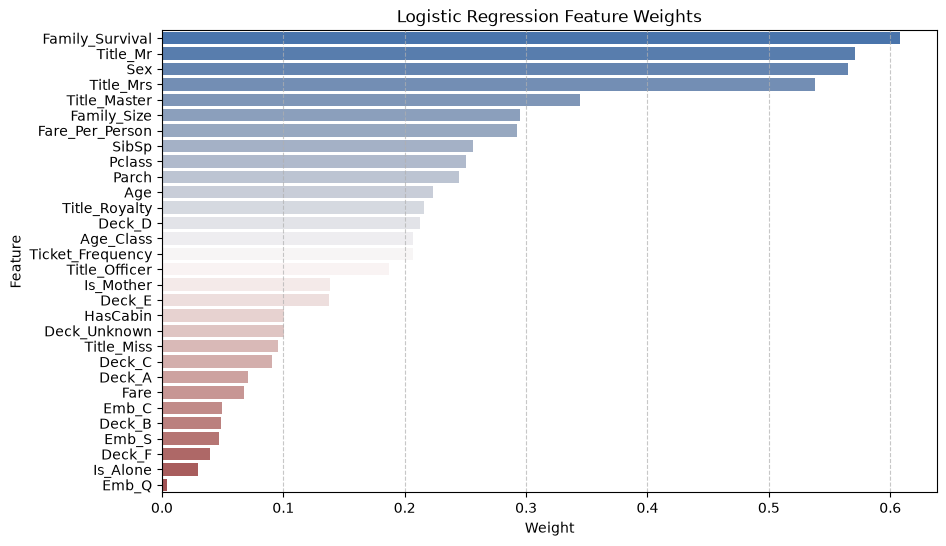

In [80]:
# Извлекаем коэффициенты
feature_names = X_lr.columns # подставьте имя ваших колонок
coefs = logreg_model.coef_[0]

# Строим датафрейм и сортируем
df_importances = pd.DataFrame({'Feature': feature_names, 'Weight': coefs})
df_importances['Weight'] = df_importances['Weight'].abs()
df_importances = df_importances.reindex(df_importances['Weight'].abs().sort_values(ascending=False).index)

# График
plt.figure(figsize=(10, 6))
sns.barplot(x='Weight', y='Feature', data=df_importances, palette='vlag')
plt.title('Logistic Regression Feature Weights')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


Какие признаки убрать для Logistic Regression:
- Emb_Q
- Deck_F
- Is_Alone

C:\Users\MSI\AppData\Local\Temp\ipykernel_10144\714382571.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_knn, palette='plasma')


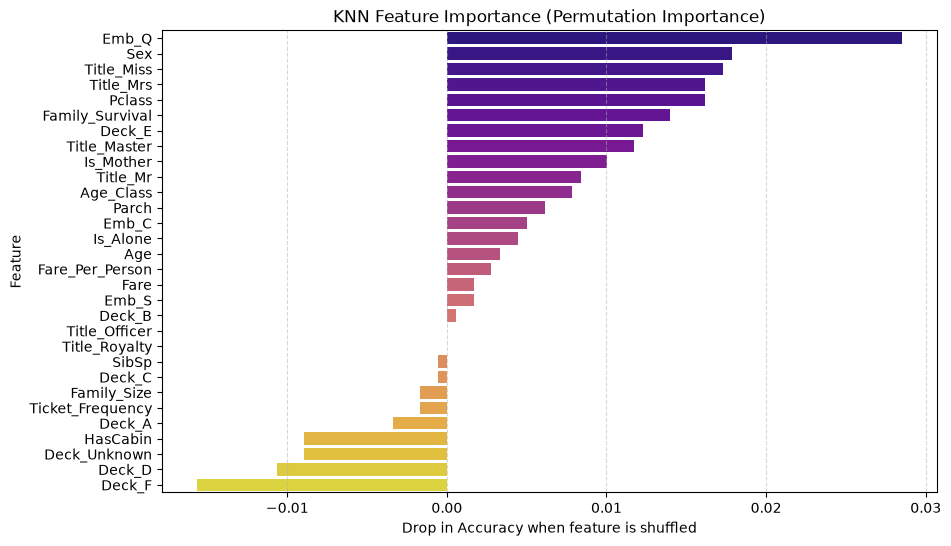

In [81]:
from sklearn.inspection import permutation_importance

# Считаем перестановочную важность на валидационной выборке
result = permutation_importance(
    knn_model, X_knn_val, y_knn_val, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)

# Собираем среднее падение точности для каждого признака
feature_names = X_knn.columns
df_knn = pd.DataFrame({'Feature': feature_names, 'Importance': result.importances_mean})
df_knn = df_knn.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_knn, palette='plasma')
plt.title('KNN Feature Importance (Permutation Importance)')
plt.xlabel('Drop in Accuracy when feature is shuffled')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()


Какие признаки убрать для KNN:
- Deck ALL
- Has_Cabin
- Ticket_Frequency
- Family_Size
- SibSp
- Title_Royalty
- Title_Officer
- Emb_S
- Fare

C:\Users\MSI\AppData\Local\Temp\ipykernel_10144\509365804.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_rf, palette='coolwarm')


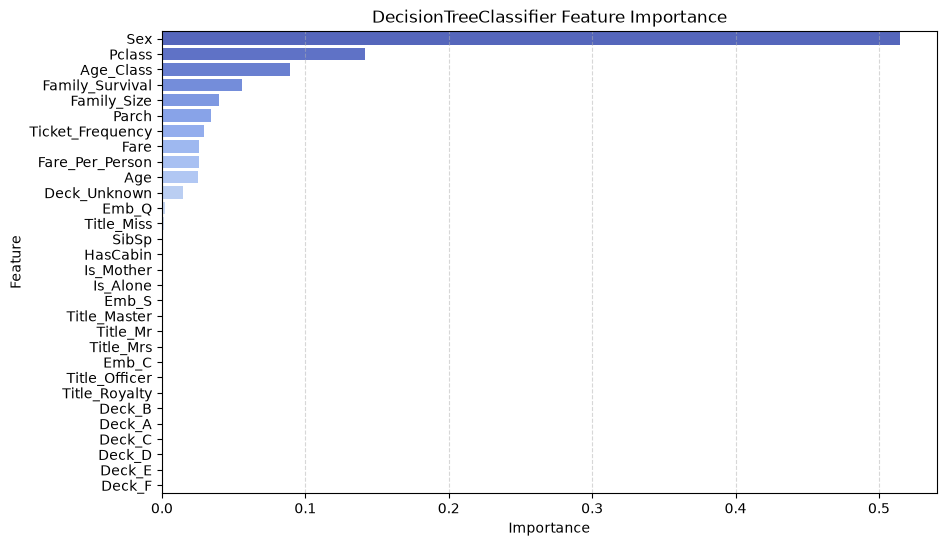

In [82]:
# Замените rf_model на tree_model, если хотите построить важность для одиночного дерева
model_to_plot = tree_model 
importances = model_to_plot.feature_importances_
feature_names = X_tree.columns # подставьте имя ваших колонок после OHE

df_rf = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
df_rf = df_rf.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_rf, palette='coolwarm')
plt.title(f'{model_to_plot.__class__.__name__} Feature Importance')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()


C:\Users\MSI\AppData\Local\Temp\ipykernel_10144\592846403.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_rf, palette='coolwarm')


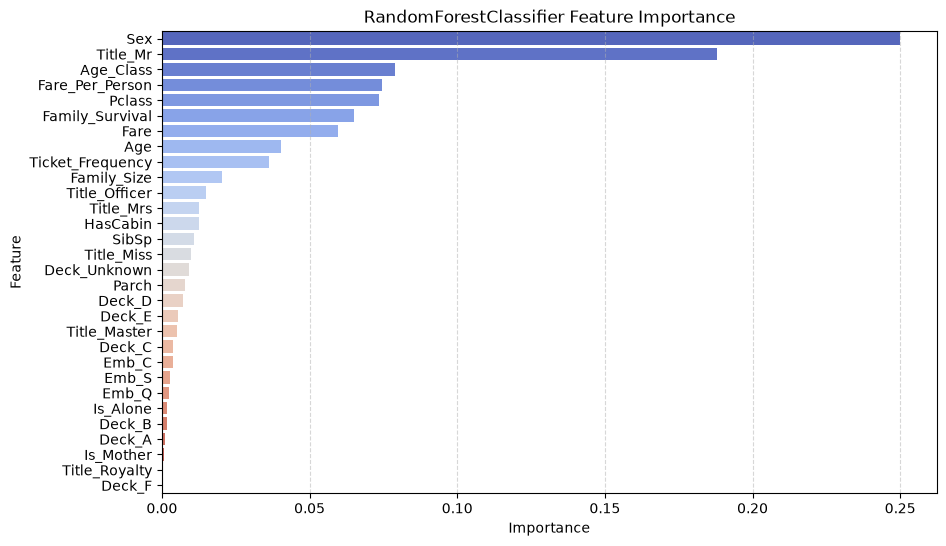

In [83]:
# Замените rf_model на tree_model, если хотите построить важность для одиночного дерева
model_to_plot = rf_model 
importances = model_to_plot.feature_importances_
feature_names = X_tree.columns # подставьте имя ваших колонок после OHE

df_rf = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
df_rf = df_rf.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_rf, palette='coolwarm')
plt.title(f'{model_to_plot.__class__.__name__} Feature Importance')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()


Какие признаки убрать для Decision Tree и Random Forest:
- Deck ALL
- Title_Royalty
- Is_Alone
- Is_Mother
- Emb ALL

C:\Users\MSI\AppData\Local\Temp\ipykernel_10144\1272920870.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_cat, palette='viridis')


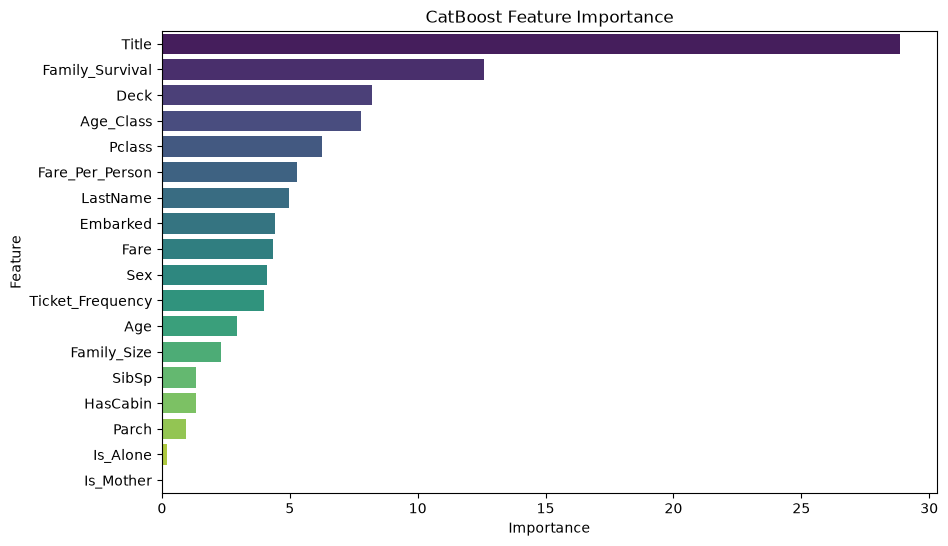

In [84]:
# Получаем важность
cat_importances = catboost_model.get_feature_importance()
cat_features_names = X_cat_train.columns # подставьте имя колонок CatBoost

df_cat = pd.DataFrame({'Feature': cat_features_names, 'Importance': cat_importances})
df_cat = df_cat.sort_values(by='Importance', ascending=False)

# График
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_cat, palette='viridis')
plt.title('CatBoost Feature Importance')
plt.show()


Какие признаки убрать для CatBoost:
- Is_Mother
- Is_Alone
- Parch
- HasCabin
- SibSp

C:\Users\MSI\AppData\Local\Temp\ipykernel_10144\2922237994.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_xgb, palette='magma')


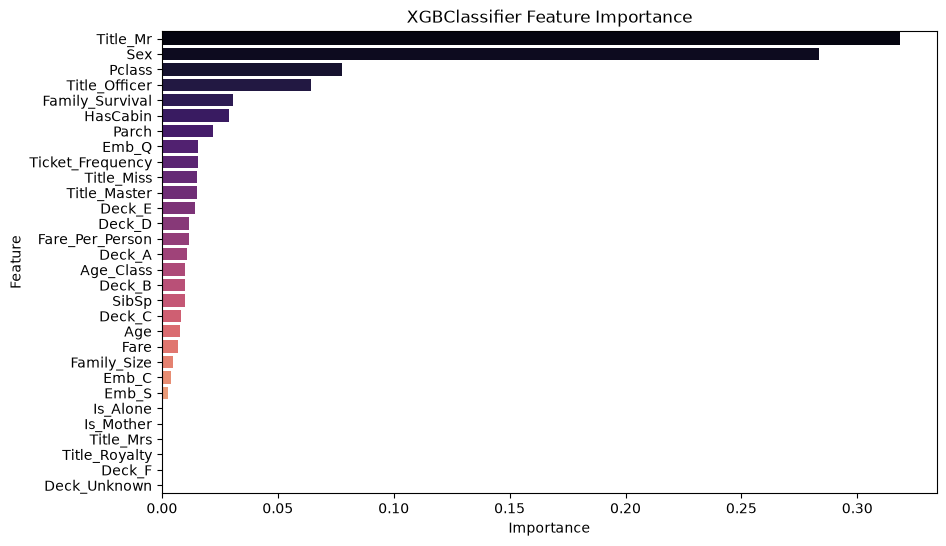

In [85]:
model_to_plot = xgb_model
xgb_importances = model_to_plot.feature_importances_
feature_names = X_xgb.columns

df_xgb = pd.DataFrame({'Feature': feature_names, 'Importance': xgb_importances})
df_xgb = df_xgb.sort_values(by='Importance', ascending=False)

# График
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_xgb, palette='magma')
plt.title(f'{model_to_plot.__class__.__name__} Feature Importance')
plt.show()

Какие признаки убрать для LightGBM:
- Deck_Unknown
- Title_Royalty
- Is_Mother
- Is_Alone
- Emb_S

C:\Users\MSI\AppData\Local\Temp\ipykernel_10144\323139963.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_xgb, palette='magma')


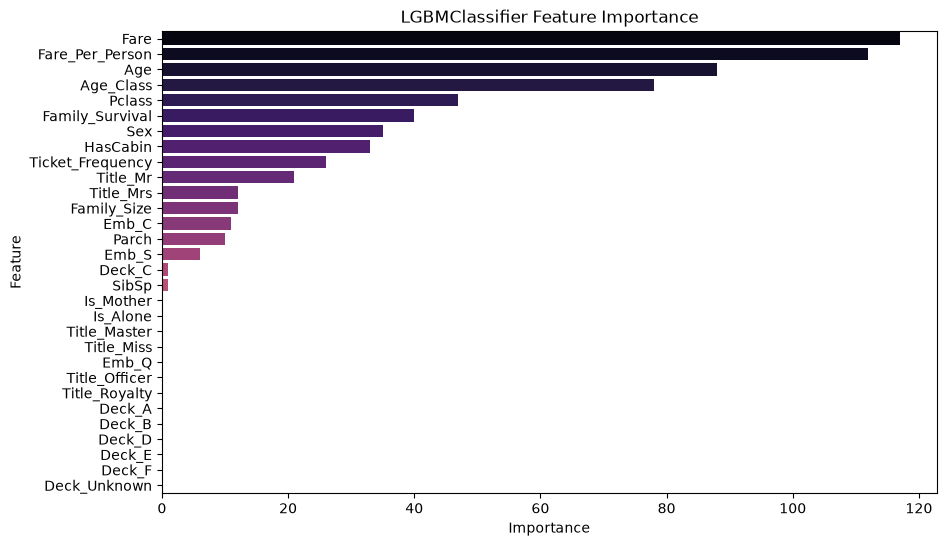

In [86]:
# Для XGBoost используйте xgb_best, для LightGBM — lgbm_best
model_to_plot = lgbm_model
xgb_importances = model_to_plot.feature_importances_
feature_names = X_lgbm.columns

df_xgb = pd.DataFrame({'Feature': feature_names, 'Importance': xgb_importances})
df_xgb = df_xgb.sort_values(by='Importance', ascending=False)

# График
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_xgb, palette='magma')
plt.title(f'{model_to_plot.__class__.__name__} Feature Importance')
plt.show()


Какие признаки убрать для LightGBM:
- Deck ALL
- Title_Royalty
- Title_Officer
- Emb_Q
- Is_alone
- Is_Mother

C:\Users\MSI\AppData\Local\Temp\ipykernel_10144\561991359.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_nn, palette='rocket')


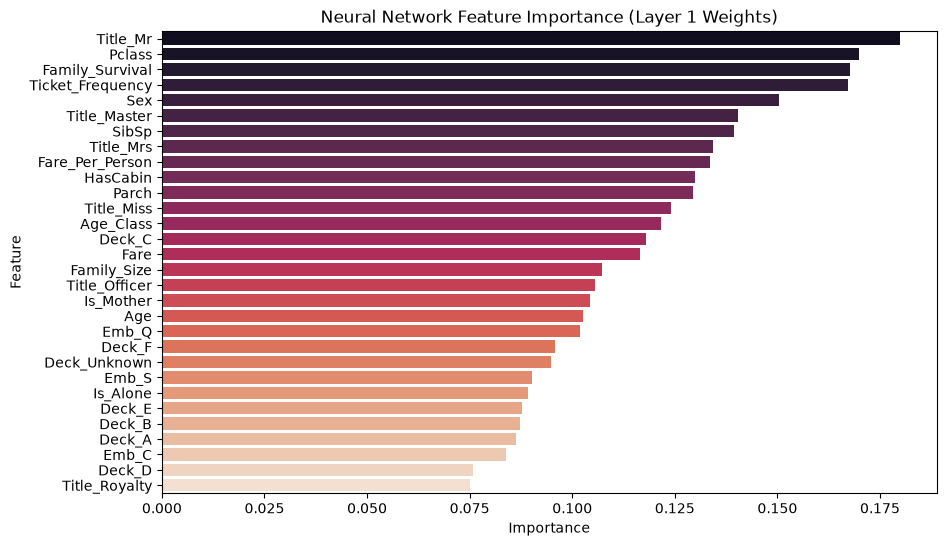

In [87]:
# Извлекаем веса первого слоя и считаем среднее абсолютное значение для каждого входа
weights = nn3_model.layer_1.weight.abs().detach().cpu().numpy()
nn_importances = np.mean(weights, axis=0)
feature_names = X_train.columns

df_nn = pd.DataFrame({'Feature': feature_names, 'Importance': nn_importances})
df_nn = df_nn.sort_values(by='Importance', ascending=False)

# График
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_nn, palette='rocket')
plt.title('Neural Network Feature Importance (Layer 1 Weights)')
plt.show()


- Is_Mother
- Deck_A

## Убираем ненужные признаки для моделей и обучаем заново

In [88]:
X_lr = X.drop(columns=['Emb_Q', 'Deck_F', 'Is_Alone'])
X_lr_train, X_lr_val, y_lr_train, y_lr_val = train_test_split(X_lr, y, test_size=0.2, random_state=RANDOM_STATE)
X_lr_train_scaled = scaler.fit_transform(X_lr_train)
X_lr_val_scaled = scaler.transform(X_lr_val)

logreg_model = get_fitted_logistic_regression(X_lr_train_scaled, y_lr_train, X_lr_val_scaled, y_lr_val, verbose=False)
stats_new['LogisticRegression'] = get_accuracy_threshold(logreg_model, X_lr_val_scaled, y_lr_val, verbose=False)

c:\Users\MSI\my\programming\ML\final_project\titanic\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [89]:
X_knn = X.drop(columns=['Deck_A', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_Unknown', 'HasCabin', 'Ticket_Frequency', 'Family_Size', 'SibSp', 'Title_Royalty', 'Title_Officer', 'Emb_S', 'Fare'])
X_knn_train, X_knn_val, y_knn_train, y_knn_val = train_test_split(X_knn, y, test_size=0.2, random_state=RANDOM_STATE)
X_knn_train = scaler.fit_transform(X_knn_train)
X_knn_val = scaler.transform(X_knn_val)

knn_model = get_fitted_knn(X_knn_train, y_knn_train, X_knn_val, y_knn_val, verbose=False)
stats_new['KNeighborsClassifier'] = get_accuracy_threshold(knn_model, X_knn_val, y_knn_val, verbose=False)

In [90]:
X_tree = X.drop(columns=['Deck_A', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_Unknown', 'Title_Royalty', 'Is_Alone', 'Is_Mother', 'Emb_C', 'Emb_Q', 'Emb_S'])

X_tree_train, X_tree_val, y_tree_train, y_tree_val = train_test_split(X_tree, y, test_size=0.2, random_state=RANDOM_STATE)
tree_model = get_fitted_decision_tree(X_tree_train, y_tree_train, X_tree_val, y_tree_val, verbose=False)
stats_new['DecisionTreeClassifier'] = get_accuracy_threshold(tree_model, X_tree_val, y_tree_val, verbose=False)

In [91]:
rf_model = get_fitted_random_forest(X_tree_train, y_tree_train, X_tree_val, y_tree_val, verbose=False)
rf_model.set_params(n_estimators=300)
rf_model.fit(X_tree_train, y_tree_train)
stats_new['RandomForestClassifier'] = get_accuracy_threshold(rf_model, X_tree_val, y_tree_val, verbose=False)

In [92]:
X_cat = train_cat.drop(columns=['Survived', 'Is_Mother', 'Is_Alone', 'Parch', 'HasCabin'])
X_cat_train, X_cat_val, y_cat_train, y_cat_val = train_test_split(X_cat, y_cat, test_size=0.2, random_state=RANDOM_STATE)
catboost_model = get_fitted_catboost(X_cat_train, y_cat_train, X_cat_val, y_cat_val, cat_features=['Embarked', 'LastName', 'Title', 'Deck'], verbose=False)
stats_new['CatBoostClassifier'] = get_accuracy_threshold(catboost_model, X_cat_val, y_cat_val, verbose=False)

In [93]:
X_lgbm = X.drop(columns=['Deck_A', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_Unknown', 'Title_Royalty', 'Title_Officer', 'Emb_Q', 'Is_Alone', 'Is_Mother'])
X_lgbm_train, X_lgbm_val, y_lgbm_train, y_lgbm_val = train_test_split(X_lgbm, y, test_size=0.2, random_state=RANDOM_STATE)
lgbm_model = get_fitted_lightgbm(X_lgbm_train, y_lgbm_train, X_lgbm_val, y_lgbm_val, verbose=False)
stats_new['LGBMClassifier'] = get_accuracy_threshold(lgbm_model, X_lgbm_val, y_lgbm_val, verbose=False)

In [94]:
X_xgb = X.drop(columns=['Deck_Unknown', 'Title_Royalty', 'Emb_S', 'Is_Alone', 'Is_Mother'])
X_xgb_train, X_xgb_val, y_xgb_train, y_xgb_val = train_test_split(X_xgb, y, test_size=0.2, random_state=RANDOM_STATE)
xgb_model = get_fitted_xgboost(X_xgb_train, y_xgb_train, X_xgb_val, y_xgb_val, verbose=False)
stats_new['XGBClassifier'] = get_accuracy_threshold(xgb_model, X_xgb_val, y_xgb_val, verbose=False)

In [95]:
X_nn = X.drop(columns=['Is_Mother', 'Deck_A'])
X_nn_train, X_nn_val, y_nn_train, y_nn_val = train_test_split(X_nn, y, test_size=0.2, random_state=RANDOM_STATE)
X_nn_train = scaler.fit_transform(X_nn_train)
X_nn_val = scaler.transform(X_nn_val)
X_train_tensor = torch.tensor(X_nn_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_nn_train.values, dtype=torch.float32).to(device)
X_val_tensor   = torch.tensor(X_nn_val, dtype=torch.float32).to(device)
y_val_tensor   = torch.tensor(y_nn_val.values, dtype=torch.float32).to(device)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

input_dim = X_train_tensor.shape[1]
nn3_model = NN3(input_dim).to(device)
class_counts = y_nn_train.value_counts()
pos_weight = torch.tensor([class_counts[0] / class_counts[1]], dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(nn3_model.parameters(), lr=0.005, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=10, factor=0.1)
nn3_model, _ = get_fitted_nn(nn3_model, train_loader, X_val_tensor, y_val_tensor, scheduler, EPOCHS=150, verbose=False)
stats_new['NN3'] = get_accuracy_threshold(nn3_model, X_val_tensor, y_nn_val, verbose=False)

In [96]:
print_sorted_stats(stats_new)

┌────────────────────────┬──────────┬───────────┐
│ Classifier             │ Accuracy │ Threshold │
├────────────────────────┼──────────┼───────────┤
│ RandomForestClassifier │ 0.9106   │ 0.35      │
│ LGBMClassifier         │ 0.9106   │ 0.35      │
│ KNeighborsClassifier   │ 0.9050   │ 0.32      │
│ CatBoostClassifier     │ 0.9050   │ 0.28      │
│ LogisticRegression     │ 0.8994   │ 0.46      │
│ XGBClassifier          │ 0.8939   │ 0.25      │
│ NN3                    │ 0.8939   │ 0.47      │
│ DecisionTreeClassifier │ 0.8715   │ 0.38      │
└────────────────────────┴──────────┴───────────┘


# Ансамбли
---

Кандидаты для ансамбля:
- XGBoost
- Random Forest
- LightGBM
- KNN
- Cat Boost
- NN3

## Усреднение

In [97]:
probs_xgb = xgb_model.predict_proba(X_xgb_val)[:, 1]
probs_rf = rf_model.predict_proba(X_tree_val)[:, 1]
probs_lgbm = lgbm_model.predict_proba(X_lgbm_val)[:, 1]
probs_knn = knn_model.predict_proba(X_knn_val)[:, 1]
probs_cb = catboost_model.predict_proba(X_cat_val)[:, 1]

nn3_model.eval()
with torch.no_grad():
    probs_nn = torch.sigmoid(nn3_model(X_val_tensor)).cpu().numpy().flatten()

probs_ensemble = (probs_xgb + probs_rf + probs_lgbm + probs_knn + probs_cb + probs_nn) / 6.0

ensemble_threshold = 0.5
ensemble_accuracy  = 0.0

for threshold in np.arange(0.1, 0.9, 0.01):
    preds_ensemble = (probs_ensemble >= threshold).astype(int)
    current_accuracy = accuracy_score(y_val, preds_ensemble)

    if current_accuracy > ensemble_accuracy:
        ensemble_threshold = threshold
        ensemble_accuracy = current_accuracy

print(f'ensemble threshold: {ensemble_threshold:.2f}')
print(f'ensemble accuracy:  {ensemble_accuracy:.4f}')

ensemble threshold: 0.33
ensemble accuracy:  0.9050


## Stacking

In [98]:
estimators = [
    ('xgb', xgb_model),
    ('rf', rf_model),
    ('lgbm', lgbm_model),
    ('knn', knn_model),
    ('cb', catboost_model)
]

### Через Логистическую регрессию

In [99]:
stacking_model_logreg = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5,
    n_jobs=-1
)

stacking_model_logreg.fit(X_lr_train, y_lr_train)
stacking_accuracy, stacking_threshold = get_accuracy_threshold(stacking_model_logreg, X_lr_val, y_lr_val)

best threshold: 0.24
best accuracy:  0.9162


### Через Ridge

In [100]:
stacking_model_ridge = StackingClassifier(
    estimators=estimators,
    final_estimator=RidgeClassifier(),
    cv=5,
    n_jobs=-1
)

stacking_model_ridge.fit(X_lr_train, y_lr_train)

y_stack_pred = stacking_model_ridge.predict(X_lr_val)
print(f'best accuracy: {accuracy_score(y_lr_val, y_stack_pred):.4f}')

best accuracy: 0.8827


### Ручной стэкинг (Предсказания вер-тей)

In [101]:
meta_features_val = {
    'xgb': xgb_model.predict_proba(X_xgb_val)[:, 1],
    'rf': rf_model.predict_proba(X_tree_val)[:, 1],
    'lgbm': lgbm_model.predict_proba(X_lgbm_val)[:, 1],
    'knn': knn_model.predict_proba(X_knn_val)[:, 1],
    'cb': catboost_model.predict_proba(X_cat_val)[:, 1]
}
nn3_model.eval()
with torch.no_grad():
    meta_features_val['nn'] = torch.sigmoid(nn3_model(X_val_tensor)).cpu().numpy().flatten()

X_meta_val = pd.DataFrame(meta_features_val)
y_meta_val = y_val.values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_probs = np.zeros(len(X_meta_val))

meta_models = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_meta_val, y_meta_val)):
    X_train_fold, X_val_fold = X_meta_val.iloc[train_idx], X_meta_val.iloc[val_idx]
    y_train_fold, y_val_fold = y_meta_val[train_idx], y_meta_val[val_idx]
    
    meta_model = LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE)
    meta_model.fit(X_train_fold, y_train_fold)
    
    # Записываем вероятности для валидационного фолда в общий массив
    oof_probs[val_idx] = meta_model.predict_proba(X_val_fold)[:, 1]
    
    # Сохраняем модель этого фолда
    meta_models.append(meta_model)


best_meta_threshold = 0.5
best_meta_accuracy = 0.0

for threshold in np.arange(0.1, 0.9, 0.01):
    meta_preds = (oof_probs >= threshold).astype(int)
    current_accuracy = accuracy_score(y_meta_val, meta_preds)
    
    if current_accuracy > best_meta_accuracy:
        best_meta_accuracy = current_accuracy
        best_meta_threshold = threshold

print(f'meta-model threshold: {best_meta_threshold:.2f}')
print(f'meta-model accuracy:  {best_meta_accuracy:.4f}')

meta-model threshold: 0.30
meta-model accuracy:  0.9106


### Ручной стэкинг (Фичи + Вероятности)

In [102]:
probs_xgb = xgb_model.predict_proba(X_xgb_val)[:, 1]
probs_rf = rf_model.predict_proba(X_tree_val)[:, 1]
probs_lgbm = lgbm_model.predict_proba(X_lgbm_val)[:, 1]
probs_knn = knn_model.predict_proba(X_knn_val)[:, 1]
probs_cb = catboost_model.predict_proba(X_cat_val)[:, 1]

nn3_model.eval()
with torch.no_grad():
    probs_nn = torch.sigmoid(nn3_model(X_val_tensor)).cpu().numpy().flatten()

X_features = X_lr.copy().drop(columns=['Emb_C', 'Emb_S', 'Age_Class', 'Deck_C', 'Deck_B', 'Deck_D', 'Deck_Unknown', 'Parch', 'Title_Mrs'])
X_meta = pd.DataFrame(X_lr_val_scaled, columns=X_lr_val.columns)
X_meta_combined = X_meta[X_features.columns].copy()
X_meta_combined['probs_xgb'] = probs_xgb
X_meta_combined['probs_rf'] = probs_rf
X_meta_combined['probs_lgbm'] = probs_lgbm
X_meta_combined['probs_knn'] = probs_knn
X_meta_combined['probs_cb'] = probs_cb
X_meta_combined['probs_nn'] = probs_nn
y_meta_combined = y_lr_val.values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_probs = np.zeros(len(X_meta_combined))
meta_models = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_meta_combined, y_meta_combined)):
    X_train_fold, X_val_fold = X_meta_combined.iloc[train_idx], X_meta_combined.iloc[val_idx]
    y_train_fold, y_val_fold = y_meta_combined[train_idx], y_meta_combined[val_idx]

    meta_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    meta_model.fit(X_train_fold, y_train_fold)

    oof_probs[val_idx] = meta_model.predict_proba(X_val_fold)[:, 1]
    meta_models.append(meta_model)

best_meta_threshold = 0.5
best_meta_accuracy = 0.0

for threshold in np.arange(0.1, 0.9, 0.01):
    meta_preds = (oof_probs >= threshold).astype(int)
    current_accuracy = accuracy_score(y_meta_combined, meta_preds)
    
    if current_accuracy > best_meta_accuracy:
        best_meta_accuracy = current_accuracy
        best_meta_threshold = threshold

print(f'BEST THRESHOLD: {best_meta_threshold:.2f}')
print(f'BEST ACCURACY:  {best_meta_accuracy:.4f}')


BEST THRESHOLD: 0.42
BEST ACCURACY:  0.8994


C:\Users\MSI\AppData\Local\Temp\ipykernel_10144\1685651460.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Weight', y='Feature', data=df_importances, palette='vlag')


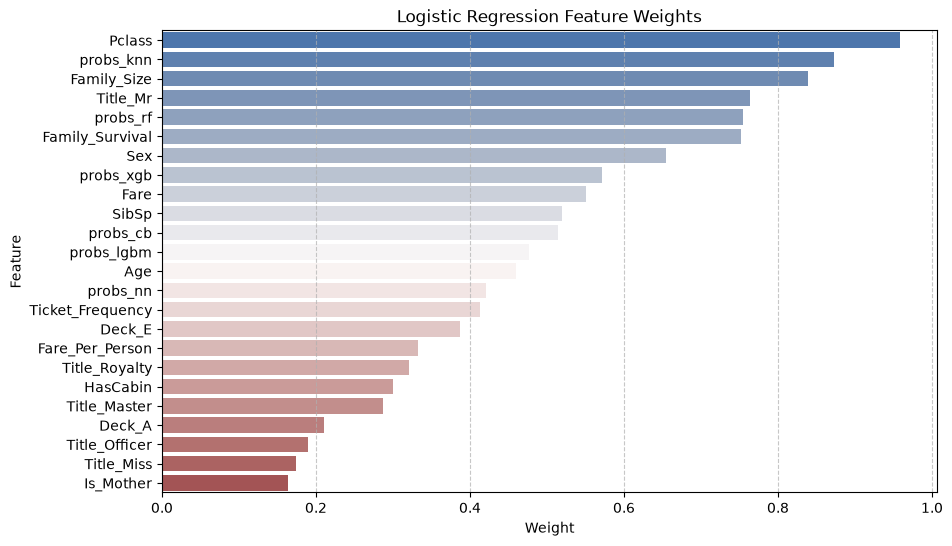

In [103]:
# Извлекаем коэффициенты
feature_names = X_meta_combined.columns # подставьте имя ваших колонок
avg_coefs = np.mean([m.coef_[0] for m in meta_models], axis=0)

# Строим датафрейм и сортируем
df_importances = pd.DataFrame({'Feature': feature_names, 'Weight': avg_coefs})
df_importances['Weight'] = df_importances['Weight'].abs()
df_importances = df_importances.reindex(df_importances['Weight'].sort_values(ascending=False).index)

# График
plt.figure(figsize=(10, 6))
sns.barplot(x='Weight', y='Feature', data=df_importances, palette='vlag')
plt.title('Logistic Regression Feature Weights')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


### Дообучаем базовые модели на 100% train

In [107]:
# --- Переобучаем sklearn-совместимые модели на 100% train, сохраняя найденные гиперпараметры ---
xgb_model_final  = clone(xgb_model).fit(X_xgb, y)     # X_xgb, X_tree, X_lgbm — уже "полные" (несплитованные) версии,
rf_model_final   = clone(rf_model).fit(X_tree, y)     # они у вас остаются в памяти после ячеек 133/136/137/132,
lgbm_model_final = clone(lgbm_model).fit(X_lgbm, y)   # просто были объявлены ДО train_test_split
knn_model_final  = clone(knn_model).fit(scaler.fit_transform(X_knn), y)

# --- CatBoost: без eval_set/early stopping, но с зафиксированным числом итераций из валидации ---
catboost_model_final = clone(catboost_model)
catboost_model_final.set_params(iterations=catboost_model.get_best_iteration() or catboost_model.tree_count_)
catboost_model_final.fit(X_cat, y_cat, cat_features=['Embarked', 'LastName', 'Title', 'Deck'])

# --- NN3: переинициализируем и обучаем на 100% данных на фиксированное число эпох ---
X_nn_full_scaled = scaler.fit_transform(X_nn)          # тот же scaler_final, что и для KNN — можно раздельные
X_nn_full_tensor = torch.tensor(X_nn_full_scaled, dtype=torch.float32).to(device)
y_nn_full_tensor = torch.tensor(y.values, dtype=torch.float32).to(device)
full_dataset = TensorDataset(X_nn_full_tensor, y_nn_full_tensor)
full_loader = DataLoader(full_dataset, batch_size=32, shuffle=True)

nn3_model_final = NN3(X_nn_full_tensor.shape[1]).to(device)
optimizer_final = optim.Adam(nn3_model_final.parameters(), lr=0.005, weight_decay=1e-4)
# без scheduler/early-stopping по val — просто фиксированное число эпох,
# равное тому, на котором остановилась ранняя версия (посмотрите на кривую обучения nn3_model)
for epoch in range(80):  # напр. 80, если nn3_model остановился на этой эпохе
    nn3_model_final.train()
    for X_batch, y_batch in full_loader:
        optimizer_final.zero_grad()
        loss = criterion(nn3_model_final(X_batch).squeeze(), y_batch)
        loss.backward()
        optimizer_final.step()

Learning rate set to 0.029947
0:	learn: 0.6738505	total: 32.7ms	remaining: 9.64s
1:	learn: 0.6556922	total: 69.3ms	remaining: 10.2s
2:	learn: 0.6387512	total: 104ms	remaining: 10.1s
3:	learn: 0.6245853	total: 130ms	remaining: 9.46s
4:	learn: 0.6126349	total: 154ms	remaining: 8.98s
5:	learn: 0.5982145	total: 179ms	remaining: 8.64s
6:	learn: 0.5878246	total: 206ms	remaining: 8.5s
7:	learn: 0.5759835	total: 249ms	remaining: 8.95s
8:	learn: 0.5662024	total: 275ms	remaining: 8.76s
9:	learn: 0.5578400	total: 302ms	remaining: 8.64s
10:	learn: 0.5480974	total: 328ms	remaining: 8.49s
11:	learn: 0.5364438	total: 351ms	remaining: 8.31s
12:	learn: 0.5271441	total: 377ms	remaining: 8.21s
13:	learn: 0.5169287	total: 400ms	remaining: 8.06s
14:	learn: 0.5081231	total: 425ms	remaining: 7.96s
15:	learn: 0.5004547	total: 450ms	remaining: 7.88s
16:	learn: 0.4933203	total: 474ms	remaining: 7.78s
17:	learn: 0.4875252	total: 497ms	remaining: 7.67s
18:	learn: 0.4820411	total: 521ms	remaining: 7.59s
19:	learn:

# Ответ для Kaggle
---

In [108]:
scaler_test = StandardScaler()
scaler_test.fit(X)

test_scaled = scaler_test.transform(test)
test_scaled = pd.DataFrame(test_scaled, columns=test.columns)

test_xgb = test.drop(columns=['Deck_Unknown', 'Title_Royalty', 'Emb_S', 'Is_Alone', 'Is_Mother'])
test_rf = test.drop(columns=['Deck_A', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_Unknown', 'Title_Royalty', 'Is_Alone', 'Is_Mother', 'Emb_C', 'Emb_Q', 'Emb_S'])
test_lgbm = test.drop(columns=['Deck_A', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_Unknown', 'Title_Royalty', 'Title_Officer', 'Emb_Q', 'Is_Alone', 'Is_Mother'])
test_knn = test_scaled.drop(columns=['Deck_A', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_Unknown', 'HasCabin', 'Ticket_Frequency', 'Family_Size', 'SibSp', 'Title_Royalty', 'Title_Officer', 'Emb_S', 'Fare'])
test_cb = test_cat.drop(columns=['Is_Mother', 'Is_Alone', 'Parch', 'HasCabin'])
test_nn = test_scaled.drop(columns=['Is_Mother', 'Deck_A'])
test_nn = torch.tensor(test_nn.values, dtype=torch.float32).to(device)

probs_xgb = xgb_model_final.predict_proba(test_xgb)[:, 1]
probs_rf = rf_model_final.predict_proba(test_rf)[:, 1]
probs_lgbm = lgbm_model_final.predict_proba(test_lgbm)[:, 1]
probs_knn = knn_model_final.predict_proba(test_knn)[:, 1]
probs_cb = catboost_model_final.predict_proba(test_cb)[:, 1]
nn3_model_final.eval()
with torch.no_grad():
    probs_nn = torch.sigmoid(nn3_model_final(test_nn)).cpu().numpy().flatten()

test_meta = test_scaled[X_features.columns]
test_meta['probs_xgb'] = probs_xgb
test_meta['probs_rf'] = probs_rf
test_meta['probs_lgbm'] = probs_lgbm
test_meta['probs_knn'] = probs_knn
test_meta['probs_cb'] = probs_cb
test_meta['probs_nn'] = probs_nn

test_oof_probs = np.zeros(len(test_meta))

# Просим каждую из 10 сохраненных моделей фолдов сделать прогноз
for meta_model in meta_models:
    test_oof_probs += meta_model.predict_proba(test_meta)[:, 1]

# Находим среднюю вероятность по всем 10 моделям
test_probs = test_oof_probs / len(meta_models)
FINAL_PREDICTIONS = (test_probs >= best_meta_threshold).astype(int)

orig_test = pd.read_csv('./data/test.csv')
submission = pd.DataFrame({
    'PassengerId': orig_test['PassengerId'],
    'Survived': FINAL_PREDICTIONS
})

submission.to_csv('output_titanic.csv', index=False)
print("DONE!")

DONE!


c:\Users\MSI\my\programming\ML\final_project\titanic\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
